In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [5]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [6]:
df1=pd.read_csv(r"D:\ai-jobs-market-analysis\data\raw\ai_job_dataset1.csv")

In [7]:
df2=pd.read_csv(r"D:\ai-jobs-market-analysis\data\raw\ai_job_dataset.csv")

In [8]:
df1.head()

,job_id,job_title,salary_usd,salary_currency,salary_local,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,benefits_score
0,AI00001,Data Scientist,219728,USD,219728,EX,PT,Sweden,M,Sweden,0,"Python, Computer Vision, R, Docker",Associate,13,Transportation,6.6
1,AI00002,Head of AI,230237,JPY,25326070,EX,PT,Japan,L,Japan,50,"Kubernetes, MLOps, Tableau, Python",Bachelor,10,Transportation,8.5
2,AI00003,Data Engineer,128890,EUR,109557,EX,CT,Germany,S,Germany,100,"Spark, Scala, Hadoop, PyTorch, GCP",Bachelor,12,Automotive,5.5
3,AI00004,Computer Vision Engineer,96349,USD,96349,MI,FL,Finland,L,Finland,50,"MLOps, Linux, Tableau, Python",PhD,2,Automotive,6.8
4,AI00005,Robotics Engineer,63065,EUR,53605,EN,FT,France,S,France,100,"R, Scala, SQL, GCP, Python",Associate,0,Finance,9.3


In [9]:
df2.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [10]:
df1.shape

(15000, 16)

In [11]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   job_id              15000 non-null  object 
 1   job_title           15000 non-null  object 
 2   salary_usd          15000 non-null  int64  
 3   salary_currency     15000 non-null  object 
 4   salary_local        15000 non-null  int64  
 5   experience_level    15000 non-null  object 
 6   employment_type     15000 non-null  object 
 7   company_location    15000 non-null  object 
 8   company_size        15000 non-null  object 
 9   employee_residence  15000 non-null  object 
 10  remote_ratio        15000 non-null  int64  
 11  required_skills     15000 non-null  object 
 12  education_required  15000 non-null  object 
 13  years_experience    15000 non-null  int64  
 14  industry            15000 non-null  object 
 15  benefits_score      15000 non-null  float64
dtypes: f

In [12]:
df1.isnull().sum()

job_id                0
job_title             0
salary_usd            0
salary_currency       0
salary_local          0
experience_level      0
employment_type       0
company_location      0
company_size          0
employee_residence    0
remote_ratio          0
required_skills       0
education_required    0
years_experience      0
industry              0
benefits_score        0
dtype: int64

In [13]:
df2.shape


(15000, 19)

In [14]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [15]:
df2.isnull().sum()

job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64

In [16]:
print(df1.columns.tolist())
print(df2.columns.tolist())

['job_id', 'job_title', 'salary_usd', 'salary_currency', 'salary_local', 'experience_level', 'employment_type', 'company_location', 'company_size', 'employee_residence', 'remote_ratio', 'required_skills', 'education_required', 'years_experience', 'industry', 'benefits_score']
['job_id', 'job_title', 'salary_usd', 'salary_currency', 'experience_level', 'employment_type', 'company_location', 'company_size', 'employee_residence', 'remote_ratio', 'required_skills', 'education_required', 'years_experience', 'industry', 'posting_date', 'application_deadline', 'job_description_length', 'benefits_score', 'company_name']


In [17]:
df1=df1.drop(columns='salary_local')

In [18]:
df2=df2.drop(columns=['company_name'])

In [19]:
df1.shape

(15000, 15)

In [20]:
df2.shape

(15000, 18)

In [21]:
# Make all column names lowercase, replace spaces with underscores
df1.columns = df1.columns.str.lower().str.replace(' ', '_')
df2.columns = df2.columns.str.lower().str.replace(' ', '_')

In [22]:
keep_cols = ['job_id', 'job_title', 'salary_usd', 'salary_currency', 'experience_level', 'employment_type', 'company_location', 'company_size', 'employee_residence', 'remote_ratio', 'required_skills', 'education_required', 'years_experience', 'industry', 'benefits_score']

df1 = df1[[col for col in keep_cols if col in df1.columns]]
df2 = df2[[col for col in keep_cols if col in df2.columns]]

In [23]:
df1['source'] = 'dataset_1'
df2['source'] = 'dataset_2'

df = pd.concat([df1, df2], ignore_index=True)
print(df.shape)
print(df.isnull().sum())

(30000, 16)
job_id                0
job_title             0
salary_usd            0
salary_currency       0
experience_level      0
employment_type       0
company_location      0
company_size          0
employee_residence    0
remote_ratio          0
required_skills       0
education_required    0
years_experience      0
industry              0
benefits_score        0
source                0
dtype: int64


In [24]:
# Drop duplicates
df = df.drop_duplicates()

# Remove unrealistic salaries (under $5k or over $500k)
df = df[df['salary_usd'] > 5000]
df = df[df['salary_usd'] < 500000]

# Standardise experience level labels if messy
print(df['experience_level'].unique())

# Standardise company size
print(df['company_size'].unique())

['EX' 'MI' 'EN' 'SE']
['M' 'L' 'S']


In [25]:
print(f"Cleaned dataset saved: {df.shape[0]} rows, {df.shape[1]} columns")

Cleaned dataset saved: 30000 rows, 16 columns


Merged both datasets. Final cleaned dataset has 30000 rows and 16 columns. Removed duplicates and salary outliers.

In [26]:
sns.set_theme(style="whitegrid")

In [27]:
print(df['salary_usd'].describe())

count     30000.000000
mean     118670.451700
std       62229.977054
min       16621.000000
25%       72575.750000
50%      103206.500000
75%      150921.750000
max      410273.000000
Name: salary_usd, dtype: float64


In [28]:
# See all categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns
print(cat_cols)

# Check unique values in each
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values → {df[col].unique()[:5]}")

Index(['job_id', 'job_title', 'salary_currency', 'experience_level',
       'employment_type', 'company_location', 'company_size',
       'employee_residence', 'required_skills', 'education_required',
       'industry', 'source'],
      dtype='object')
job_id: 15000 unique values → ['AI00001' 'AI00002' 'AI00003' 'AI00004' 'AI00005']
job_title: 20 unique values → ['Data Scientist' 'Head of AI' 'Data Engineer' 'Computer Vision Engineer'
 'Robotics Engineer']
salary_currency: 8 unique values → ['USD' 'JPY' 'EUR' 'SGD' 'CAD']
experience_level: 4 unique values → ['EX' 'MI' 'EN' 'SE']
employment_type: 4 unique values → ['PT' 'CT' 'FL' 'FT']
company_location: 20 unique values → ['Sweden' 'Japan' 'Germany' 'Finland' 'France']
company_size: 3 unique values → ['M' 'L' 'S']
employee_residence: 50 unique values → ['Sweden' 'Japan' 'Germany' 'Finland' 'France']
required_skills: 25702 unique values → ['Python, Computer Vision, R, Docker' 'Kubernetes, MLOps, Tableau, Python'
 'Spark, Scala, Hadoop, P

In [29]:
title_counts = df['job_title'].value_counts()

df['job_title_grouped'] = df['job_title'].apply(
    lambda x: x if title_counts[x] >= 8 else 'Other'
)

print(df['job_title_grouped'].nunique())

20


In [30]:
cmpy_counts = df['company_location'].value_counts()

df['location_grouped'] = df['company_location'].apply(
    lambda x: x if cmpy_counts[x] >= 5 else 'Other'
)

print(df['location_grouped'].nunique())

20


In [31]:
residence_counts = df['employee_residence'].value_counts()

df['residence_grouped'] = df['employee_residence'].apply(
    lambda x: x if residence_counts[x] >= 10 else 'Other'
)

print(df['residence_grouped'].nunique())

50


In [32]:
industry_counts = df['industry'].value_counts()

df['industry_grouped'] = df['industry'].apply(
    lambda x: x if industry_counts[x] >= 10 else 'Other'
)

print(df['industry_grouped'].nunique())

15


In [33]:
skills_counts = df['required_skills'].value_counts()

df['skills_grouped'] = df['required_skills'].apply(
    lambda x: x if skills_counts[x] >= 10 else 'Other'
)

print(df['skills_grouped'].nunique())

13


In [34]:
le=LabelEncoder()

In [35]:
df['salary_currency']=le.fit_transform(df['salary_currency'])

In [36]:
le1=LabelEncoder()

In [37]:
df['experience_level']=le1.fit_transform(df['experience_level'])

In [38]:
le2=LabelEncoder()

In [39]:
df['employment_type']=le2.fit_transform(df['employment_type'])

In [40]:
le3=LabelEncoder()

In [41]:
df['company_size']=le3.fit_transform(df['company_size'])

In [42]:
le4=LabelEncoder()

In [43]:
df['education_required']=le4.fit_transform(df['education_required'])

In [44]:
le5=LabelEncoder()

In [45]:
df['job_title_grouped']=le5.fit_transform(df['job_title_grouped'])

In [46]:
le6=LabelEncoder()

In [47]:
df['location_grouped']=le6.fit_transform(df['location_grouped'])

In [48]:
le7=LabelEncoder()

In [49]:
df['residence_grouped']=le7.fit_transform(df['residence_grouped'])

In [50]:
le8=LabelEncoder()

In [51]:
df['skills_grouped']=le8.fit_transform(df['skills_grouped'])

In [52]:
le9=LabelEncoder()

In [53]:
df['industry_grouped']=le9.fit_transform(df['industry_grouped'])

<Axes: >

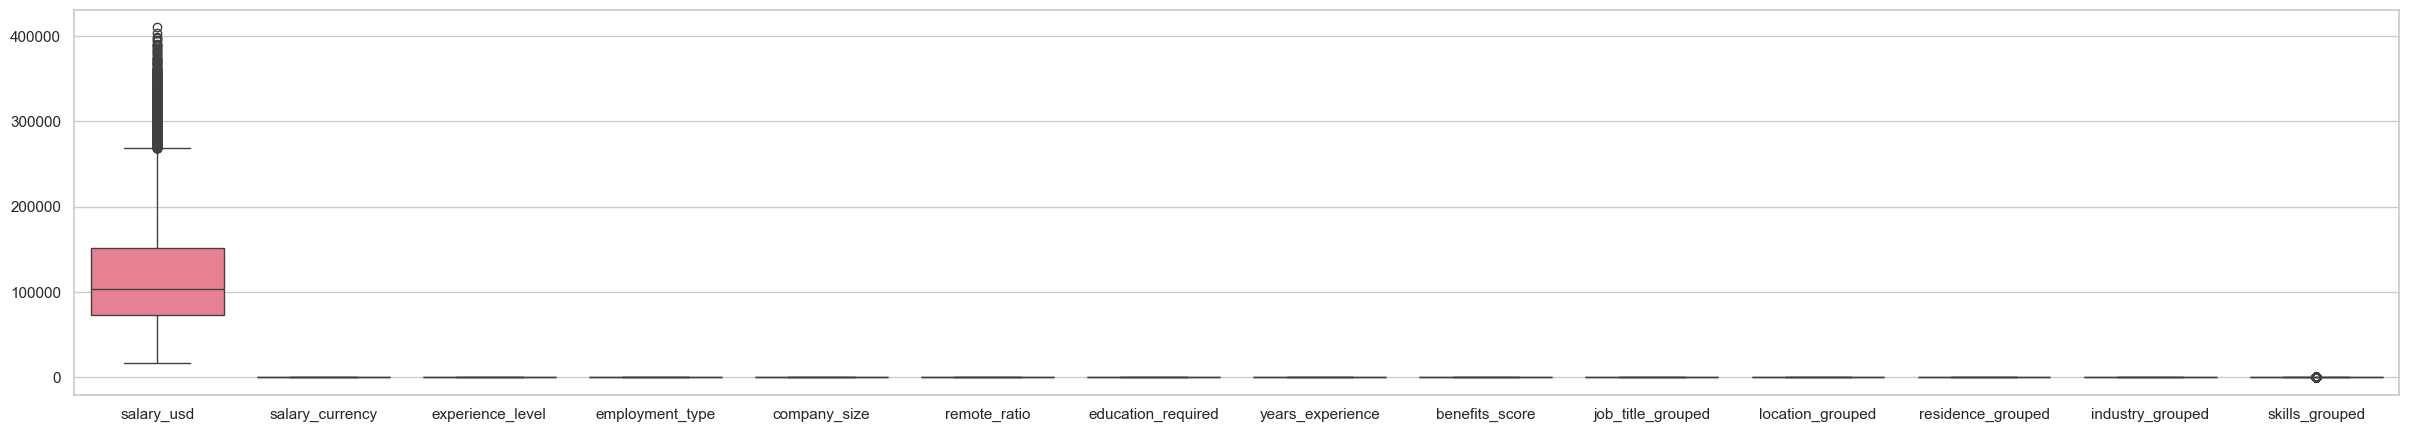

In [54]:
plt.figure(figsize=(30,5))   #to check outliers
sns.boxplot(df)

In [55]:
df.columns

Index(['job_id', 'job_title', 'salary_usd', 'salary_currency',
       'experience_level', 'employment_type', 'company_location',
       'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'benefits_score',
       'source', 'job_title_grouped', 'location_grouped', 'residence_grouped',
       'industry_grouped', 'skills_grouped'],
      dtype='object')

In [56]:
features = [ 'salary_currency',
       'experience_level', 'employment_type', 
       'company_size', 'remote_ratio', 
       'education_required', 'years_experience', 'benefits_score', 'job_title_grouped', 'location_grouped', 'residence_grouped',
       'skills_grouped', 'industry_grouped']
target = 'salary_usd'

df_model = df[features + [target]].copy()

In [57]:
X=df_model[features]
y=df_model[target]

In [58]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=1)

In [59]:
X_train.shape,X_test.shape

((21000, 13), (9000, 13))

In [60]:
y_train.shape,y_test.shape

((21000,), (9000,))

In [61]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21000 entries, 4936 to 29733
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   salary_currency     21000 non-null  int64  
 1   experience_level    21000 non-null  int64  
 2   employment_type     21000 non-null  int64  
 3   company_size        21000 non-null  int64  
 4   remote_ratio        21000 non-null  int64  
 5   education_required  21000 non-null  int64  
 6   years_experience    21000 non-null  int64  
 7   benefits_score      21000 non-null  float64
 8   job_title_grouped   21000 non-null  int64  
 9   location_grouped    21000 non-null  int64  
 10  residence_grouped   21000 non-null  int64  
 11  skills_grouped      21000 non-null  int64  
 12  industry_grouped    21000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 2.2 MB


In [62]:
sc = MinMaxScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [63]:
r=RandomForestRegressor()
d=DecisionTreeRegressor()
h=GradientBoostingRegressor() 

model=[r,d,h]

for i in model:
    print('  ',i)
    print('***************************')
    i.fit(X_train,y_train)
    y_pred=i.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    # results[i] = {'MAE': mae, 'R2': r2}
    print(f" MAE: ${mae:,.0f} | R²: {r2:.3f}")
    print()

   RandomForestRegressor()
***************************
 MAE: $17,425 | R²: 0.849

   DecisionTreeRegressor()
***************************
 MAE: $22,498 | R²: 0.731

   GradientBoostingRegressor()
***************************
 MAE: $17,279 | R²: 0.854



In [64]:
l=LinearRegression()
xg=XGBRegressor()
k=KNeighborsRegressor()

scaled_models=[l,xg,k]

for i in scaled_models:
    print('  ',i)
    print('************************************')
    i.fit(X_train_scaled,y_train)
    y_pred=i.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f" MAE: ${mae:,.0f} | R²: {r2:.3f}")
    print()


   LinearRegression()
************************************
 MAE: $26,513 | R²: 0.640

   XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)
************************************
 MAE: $17,353 | R²: 0.850

   KNeighborsRegressor()
************************************
 MAE: $26,296 | R²: 0.645



In [65]:
from sklearn.model_selection import cross_val_score
print("Cross validation score for all models on training data:")
for i in model:
    print("          ",i.__class__.__name__)
    print("***************")
    cv_r2 = cross_val_score(i,X,y,cv=5,scoring='r2')
    cv_mae = cross_val_score(i,X,y,cv=5,scoring='neg_mean_absolute_error')
    print(f"CV R² scores: {cv_r2}")
    print(f"Mean R²: {cv_r2.mean():.3f}")
    print(f"Mean MAE: ${(-cv_mae.mean()):,.0f}")

Cross validation score for all models on training data:
           RandomForestRegressor
***************
CV R² scores: [0.83768722 0.84890799 0.85270314 0.83642655 0.83489957]
Mean R²: 0.842
Mean MAE: $17,951
           DecisionTreeRegressor
***************
CV R² scores: [0.72065568 0.73273567 0.7195117  0.70978593 0.70553569]
Mean R²: 0.718
Mean MAE: $23,107
           GradientBoostingRegressor
***************
CV R² scores: [0.83502885 0.84541879 0.85684679 0.83865886 0.84776491]
Mean R²: 0.845
Mean MAE: $17,973


In [66]:
from sklearn.model_selection import cross_val_score
print("Cross validation score for all models on training data:")
for i in scaled_models:
    print("          ",i.__class__.__name__)
    print("*********************************")
    cv_r2 = cross_val_score(i,X,y,cv=5,scoring='r2')
    cv_mae = cross_val_score(i,X,y,cv=5,scoring='neg_mean_absolute_error')
    print(f"CV R² scores: {cv_r2}")
    print(f"Mean R²: {cv_r2.mean():.3f}")
    print(f"Mean MAE: ${(-cv_mae.mean()):,.0f}")

Cross validation score for all models on training data:
           LinearRegression
*********************************
CV R² scores: [0.64134439 0.64002776 0.63245301 0.60339059 0.61628086]
Mean R²: 0.627
Mean MAE: $27,042
           XGBRegressor
*********************************
CV R² scores: [0.8367486  0.84665197 0.85554135 0.83340132 0.83829576]
Mean R²: 0.842
Mean MAE: $17,953
           KNeighborsRegressor
*********************************
CV R² scores: [0.67396964 0.67219929 0.66340849 0.61993862 0.63706554]
Mean R²: 0.653
Mean MAE: $26,146


In [67]:
from sklearn.model_selection import RandomizedSearchCV

print("Starting Hyperparameter Tuning for XGBoost Regressor...")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb = XGBRegressor(random_state=42)

search = RandomizedSearchCV(
    xgb, param_grid,
    n_iter=20,
    scoring='r2',
    cv=5,
    random_state=42,
    verbose=1
)

search.fit(X_train_scaled, y_train)

print(f"Best params: {search.best_params_}")
print(f"Best CV R²: {search.best_score_:.3f}")

# Evaluate on test set
y_pred_best = search.best_estimator_.predict(X_test_scaled)
print(f"Test R²: {r2_score(y_test, y_pred_best):.3f}")
print(f"Test MAE: ${mean_absolute_error(y_test, y_pred_best):,.0f}")

Starting Hyperparameter Tuning for XGBoost Regressor...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best CV R²: 0.865
Test R²: 0.864
Test MAE: $16,782


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error

print("Starting Hyperparameter Tuning for RandomForest Regressor...")

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters found: {grid_search.best_params_}")
print(f"Best CV R² Score: {grid_search.best_score_:.4f}")

R = grid_search.best_estimator_

y_pred_r = R.predict(X_test)

test_r2 = r2_score(y_test, y_pred_r)
test_mae = mean_absolute_error(y_test, y_pred_r)

print(f"Test R²: {test_r2:.4f}")
print(f"Test MAE: {test_mae:.4f}")

Starting Hyperparameter Tuning for RandomForest Regressor...
Best Parameters found: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best CV R² Score: 0.8582
Test R²: 0.8591
Test MAE: 16991.0462


In [69]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error

print("Starting Hyperparameter Tuning for Gradient Boosting Regressor...")

param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

gb = GradientBoostingRegressor(random_state=1)

grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters found: {grid_search.best_params_}")
print(f"Best CV R² Score: {grid_search.best_score_:.4f}")

G = grid_search.best_estimator_

y_pred_g = G.predict(X_test)

test_r2 = r2_score(y_test, y_pred_g)
test_mae = mean_absolute_error(y_test, y_pred_g)

print(f"Test R²: {test_r2:.4f}")
print(f"Test MAE: {test_mae:.4f}")

Starting Hyperparameter Tuning for Gradient Boosting Regressor...
Best Parameters found: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best CV R² Score: 0.8645
Test R²: 0.8635
Test MAE: 16805.3099


In [71]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(search.best_estimator_, '../models/xgboost_salary_predictor.pkl')
print("Model saved.")

Model saved.


## Project Summary

### AI Jobs Market Analysis & Salary Predictor

**Objective:** Predict AI/data science job salaries based on experience, 
skills, education, location, and industry using machine learning.

**Dataset:** Global AI Job Market Trends 2025 — 15,000 rows, 16 features
including required skills, years of experience, education level, and industry.

**Models Trained:** Linear Regression, KNN, Random Forest, 
Gradient Boosting, XGBoost

**Final Model:** XGBoost Regressor (after hyperparameter tuning)
- Test R²: 0.864
- Test MAE: $16,782
- Best Params: n_estimators=100, max_depth=5, learning_rate=0.1

**Key Findings:**
- Years of experience and required skills were the strongest salary predictors
- Executive roles average significantly higher than entry level
- Remote roles are dominant in AI/data science globally
- Tuning XGBoost with RandomizedSearchCV improved R² from 0.842 to 0.864

**Limitations:**
- Salary figures reflect global mixed data, not region-specific markets

In [73]:
df.to_csv(r'D:\ai-jobs-market-analysis\data\processed/cleaned_jobs.csv', index=False)
print(f"Saved: {df.shape}")

Saved: (30000, 21)


In [74]:
df

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,...,education_required,years_experience,industry,benefits_score,source,job_title_grouped,location_grouped,residence_grouped,industry_grouped,skills_grouped
0,AI00001,Data Scientist,219728,7,1,3,Sweden,1,Sweden,0,...,0,13,Transportation,6.6,dataset_1,10,16,42,14,2
1,AI00002,Head of AI,230237,5,1,3,Japan,0,Japan,50,...,1,10,Transportation,8.5,dataset_1,12,11,23,14,2
2,AI00003,Data Engineer,128890,3,1,0,Germany,2,Germany,100,...,1,12,Automotive,5.5,dataset_1,9,7,15,0,2
3,AI00004,Computer Vision Engineer,96349,7,2,1,Finland,0,Finland,50,...,3,2,Automotive,6.8,dataset_1,7,5,13,0,2
4,AI00005,Robotics Engineer,63065,3,0,2,France,2,France,100,...,0,0,Finance,9.3,dataset_1,19,6,14,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,AI14996,Robotics Engineer,38604,7,0,1,Finland,2,Finland,50,...,1,1,Energy,7.9,dataset_2,19,5,13,3,2
29996,AI14997,Machine Learning Researcher,57811,4,0,0,United Kingdom,1,United Kingdom,0,...,2,0,Government,8.2,dataset_2,15,18,47,6,2
29997,AI14998,NLP Engineer,189490,7,1,0,South Korea,0,South Korea,50,...,0,17,Manufacturing,7.4,dataset_2,16,15,40,8,2
29998,AI14999,Head of AI,79461,3,0,2,Netherlands,1,Netherlands,0,...,3,1,Real Estate,5.6,dataset_2,12,12,29,10,2


In [ ]:
D:\ai-jobs-market-analysis\data\processed